In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt # data visualization (e.g plot graphs)
import seaborn as sns #  creates informative statistical graphics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import tensorflow as tf # building and training neural networks
import xgboost as xgb # for building and training neural networks
import os

In [3]:
# import csv

# # Open the input text file in read mode and the output CSV file in write mode
# with open('PRANAV_256.txt', 'r') as txtfile, open('PRANAV_256.csv', 'w', newline='') as csvfile:
#     # Specify the delimiter used in the text file (e.g., '\t' for tab-separated values)
#     delimiter = ','
    
#     # Create a CSV writer object
#     csvwriter = csv.writer(csvfile, delimiter=',')

#     # Read each line from the text file and write it to the CSV file
#     for line in txtfile:
#         # Split the line into values based on the delimiter
#         values = line.strip().split(delimiter)
        
#         # Write the values to the CSV file
#         csvwriter.writerow(values)

# print("Conversion complete. Output saved in output.csv")

In [4]:
df=pd.read_csv('PRANAV2_256.csv')

In [5]:
df.tail(40)

,0.00390625000,0.000,0.000.1,Unnamed: 3
40279,157.347656,65.377,35.431,NaN
40280,157.351562,63.447,38.291,NaN
40281,157.355469,61.698,40.883,NaN
40282,157.359375,60.112,43.233,NaN
40283,157.363281,58.675,45.362,NaN
40284,157.367188,57.372,47.293,NaN
40285,157.371094,56.191,49.042,NaN
40286,157.375000,55.121,50.628,NaN
40287,157.378906,54.151,52.066,NaN
40288,157.382812,52.905,52.885,NaN


In [6]:
df.rename(columns={'0.00390625000': 'time'}, inplace=True)

In [7]:
df.rename(columns={'0.000': 'Middle Delt'}, inplace=True)

In [8]:
df.rename(columns={'0.000.1': 'Lower Peck'}, inplace=True)

In [9]:
df.drop(columns='Unnamed: 3')

,time,Middle Delt,Lower Peck
0,0.007812,0.000,0.000
1,0.011719,0.000,0.000
2,0.015625,0.000,0.000
3,0.019531,0.000,0.000
4,0.023438,0.000,0.000
...,...,...,...
40314,157.484375,10.425,29.440
40315,157.488281,9.920,28.949
40316,157.492188,9.463,28.505
40317,157.496094,9.048,28.102


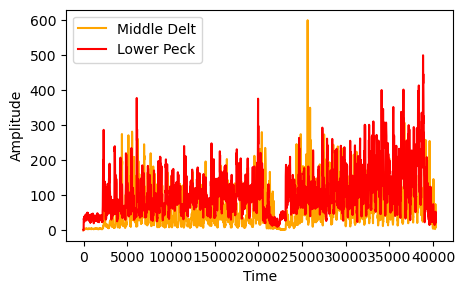

In [13]:
plt.figure(figsize=(5, 3))
plt.plot(df['Middle Delt'], color='orange', label='Middle Delt')
plt.plot(df['Lower Peck'], color='red', label='Lower Peck')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.show()

In [10]:
def calculate_rms(column_values,window_size=10000,overlap=100):
    rms_values = []
    for i in range(0, len(column_values) - window_size + 1, overlap):
        window = column_values[i:i + window_size]
        rms = np.sqrt(np.mean(window**2))
        rms_values.append(rms)
    return rms_values


In [11]:
rms_column1 = calculate_rms(df['Middle Delt'].values)
rms_column2 = calculate_rms(df['Lower Peck'].values)

# Create a new DataFrame to store RMS values
rms_df = pd.DataFrame({'RMS_Column1': rms_column1, 'RMS_Column2': rms_column2})

# Append RMS values to the original DataFrame
result_df = pd.concat([df, rms_df], axis=1)


In [12]:
rms_df.head()

,RMS_Column1,RMS_Column2
0,66.226114,90.626570
1,66.669009,91.155377
2,66.679567,91.926984
3,66.761778,92.799234
4,66.970864,93.378131


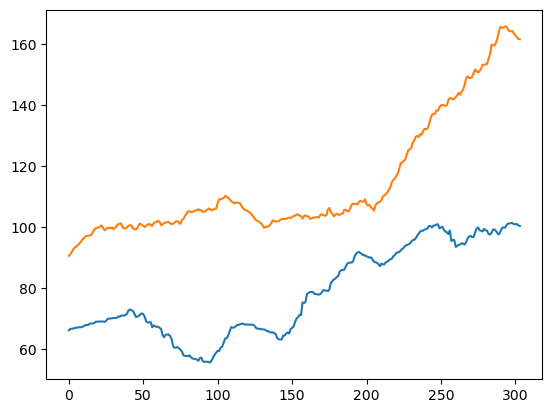

In [13]:
plt.plot(rms_df)